# Notebook 04: Filtering, spectra and signal-to-noise

**Goal (about 1.5 hours):** apply the signal-processing steps that come before any splitting measurement, and see that each one is a choice with consequences.

This is the lesson closest to an ECE course. Read along with ObsPy's [Filtering Seismograms](https://docs.obspy.org/tutorial/code_snippets/filtering_seismograms.html) page and Seismo-Live's [07 Basic Processing Exercise](https://seismo-live.github.io/html/ObsPy/07_Basic_Processing_Exercise_wrapper.html).

In [1]:
# --- setup: make the repo importable and keep figures inline ---
import sys, warnings
from pathlib import Path
REPO = Path.cwd().parent if (Path.cwd() / "../rainier_sws").exists() else Path.cwd()
sys.path.insert(0, str(REPO))
warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
from rainier_sws import paths, data, measure, quality, stats
print("repo:", REPO)

repo: /home/claude/rainier-sws-tutorials


In [2]:
import obspy
cat = data.load_station_catalog("STAR")
row = cat[cat.evid == 61504668].iloc[0]
ev = data.get_event_stream("STAR", row, allow_download=False)
origin, p_time, s_time, p_off, s_off = measure.pick_offsets(ev, row)
fs = ev[0].stats.sampling_rate
print("sampling rate", fs, "Hz; P at", round(p_off, 2), "s, S at", round(s_off, 2), "s after trace start")

sampling rate 100.0 Hz; P at 5.88 s, S at 6.47 s after trace start


## 1. What is in the signal: the spectrum

Compute the amplitude spectrum of a short window around the S wave on one horizontal channel, and of a noise window before P. The ratio of the two is where the "signal" lives in frequency.

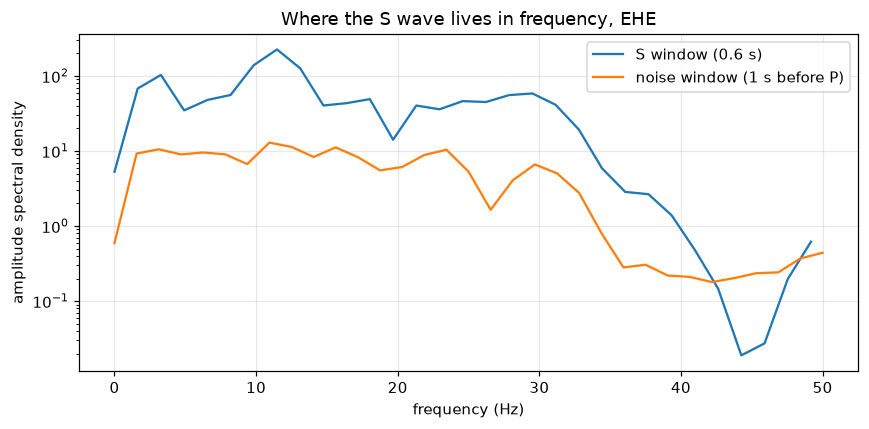

In [3]:
from scipy.signal import welch
tr = ev.select(channel="??E")[0].copy().detrend("linear")
def window(tr, t_start, t_end):
    return tr.slice(tr.stats.starttime + t_start, tr.stats.starttime + t_end).data.astype(float)
s_win = window(tr, s_off - 0.1, s_off + 0.5)
n_win = window(tr, p_off - 1.2, p_off - 0.2)
f_s, P_s = welch(s_win, fs=fs, nperseg=64); f_n, P_n = welch(n_win, fs=fs, nperseg=64)
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(f_s, np.sqrt(P_s), label="S window (0.6 s)"); ax.semilogy(f_n, np.sqrt(P_n), label="noise window (1 s before P)")
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("amplitude spectral density"); ax.legend()
ax.set_title("Where the S wave lives in frequency, EHE")
plt.tight_layout()

The S energy is concentrated roughly between 3 and 15 Hz. Below 2 Hz the noise (microseisms, wind) is comparable to or larger than the signal; above 20 Hz the signal has decayed into the noise too. A bandpass filter keeps the part of the spectrum where the earthquake wins.

## 2. Bandpass filtering

ObsPy wraps scipy's Butterworth design. `corners` is the filter order; `zerophase=True` runs it forwards and backwards so arrival times are not shifted (important when the quantity you measure is a 0.02 s delay!). Watch how the same S wave looks through three different bands.

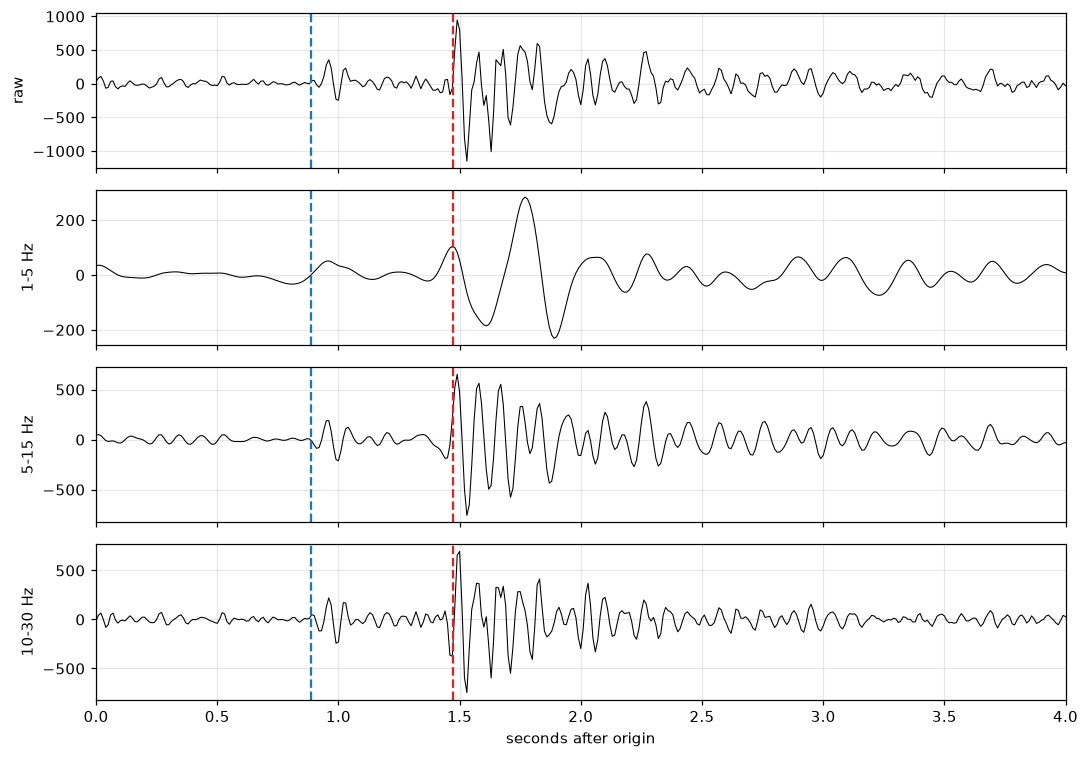

In [4]:
bands = [(1, 5), (5, 15), (10, 30)]
fig, axes = plt.subplots(len(bands) + 1, 1, figsize=(10, 7), sharex=True)
t = tr.times(reftime=origin)
axes[0].plot(t, tr.data, "k", lw=0.7); axes[0].set_ylabel("raw")
for ax, (lo, hi) in zip(axes[1:], bands):
    f = tr.copy().filter("bandpass", freqmin=lo, freqmax=hi, corners=2, zerophase=True)
    ax.plot(t, f.data, "k", lw=0.7); ax.set_ylabel(f"{lo}-{hi} Hz")
for ax in axes:
    ax.axvline(p_time - origin, color="tab:blue", ls="--"); ax.axvline(s_time - origin, color="tab:red", ls="--")
axes[-1].set_xlabel("seconds after origin"); axes[-1].set_xlim(0, 4)
plt.tight_layout()

## 3. Signal-to-noise ratio, defined precisely

"SNR" means nothing until you say which windows and which statistic. The research pipeline uses an MFAST/Baillard-style definition: mean absolute amplitude in a window after the S pick divided by mean absolute amplitude in a window before it, averaged over the two horizontal channels. Here is a simple version so you see the idea; the pipeline's exact version is `sws_functions._s_wave_snr_prefiltered`.

In [5]:
def simple_snr(tr, s_off, pre=0.4, post=0.2):
    sig = window(tr, s_off, s_off + post); noise = window(tr, s_off - pre, s_off)
    return np.mean(np.abs(sig)) / np.mean(np.abs(noise))
for lo, hi in bands:
    f = tr.copy().filter("bandpass", freqmin=lo, freqmax=hi, corners=2, zerophase=True)
    print(f"{lo:>3}-{hi:<3} Hz  SNR = {simple_snr(f, s_off):5.2f}")
print(f"raw        SNR = {simple_snr(tr, s_off):5.2f}")

  1-5   Hz  SNR =  5.97
  5-15  Hz  SNR =  8.08
 10-30  Hz  SNR =  5.92
raw        SNR =  7.92


## 4. The filter bank: letting the data choose the band

Rather than pick one band for all 900 events, the pipeline tries 14 candidate bands (from MFAST, Savage et al., 2010) and keeps the one with the highest S-wave SNR for each event. That is adaptive, but it is also a *choice* made by an SNR estimate that is itself noisy. Let's look at the SNR landscape across the bank for our event.

chosen band: (5.0, 10.0)  SNR: 8.5  dominant period (samples): 10.741258741258742


Text(0.5, 1.0, '14-band filter bank for evid 61504668 at STAR')

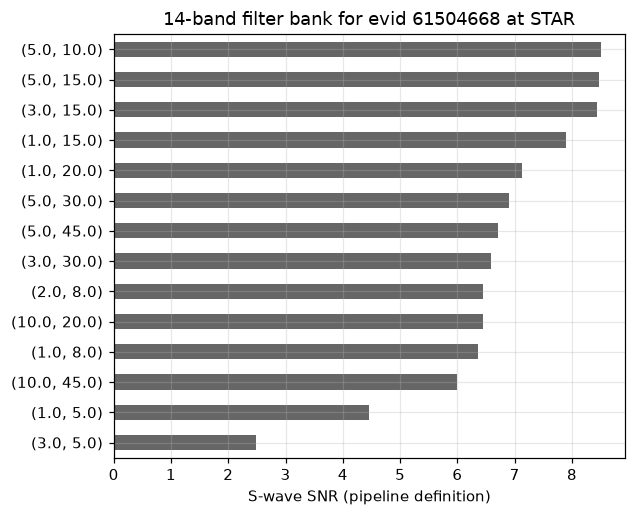

In [6]:
from rainier_sws import sws_functions as swsf
band, best_stream, snr, domp, snr_by_band = swsf.try_filters(ev.copy(), p_time, s_time)
tab = pd.Series(snr_by_band).sort_values(ascending=False)
print("chosen band:", band, " SNR:", round(snr, 2), " dominant period (samples):", domp)
ax = tab.plot.barh(figsize=(6, 5), color="0.4"); ax.set_xlabel("S-wave SNR (pipeline definition)"); ax.invert_yaxis()
ax.set_title("14-band filter bank for evid 61504668 at STAR")

Notice that several bands are close to the top. If the second-best band had been chosen, would the splitting answer change? That is exactly the kind of question notebook 08 asks, and the reason the band is recorded in every results row (`filter_band`).

## 5. Dominant period

Splitting delay times are compared with the wave's dominant period: a delay longer than half a period is almost certainly a cycle skip (the grid search matched the wrong wiggle). The pipeline estimates the dominant period from the filtered S window with a Welch spectrum (Baillard et al., 2014, as implemented in SWSPy).

In [7]:
from swspy.splitting.split_windowcheck import get_dominant_period_baillard
seg = window(best_stream.select(channel="??E")[0], s_off - 0.02, s_off + 0.3)
T_samples, f_dom = get_dominant_period_baillard(seg, fs)   # returns (period in samples, frequency in Hz)
print(f"dominant period = {T_samples:.1f} samples = {T_samples / fs:.3f} s  ->  dominant frequency {f_dom:.1f} Hz")
print(f"half-period cycle-skip limit on dt = {T_samples / fs / 2:.3f} s")

dominant period = 10.2 samples = 0.102 s  ->  dominant frequency 9.8 Hz
half-period cycle-skip limit on dt = 0.051 s


## 6. Exercises

1. Change `corners` to 4 and `zerophase` to False in section 2. Measure the shift of the S onset by eye. Why does the pipeline insist on zero-phase filters?
2. Change the SNR window lengths (`pre`, `post`) in `simple_snr` to 0.2/0.1 and 1.0/0.5. How much does the SNR move? Would the event pass an "SNR at least 2" gate under each?
3. Run the filter bank on five more events from `cat`. How often is the chosen band 5-10 or 5-15 Hz? Is there one band that would be a sensible fixed choice?
4. (Stretch) Compute the spectrogram of the whole 20 s trace (`scipy.signal.spectrogram`). Where do P, S and coda sit in time and frequency?

Next: `05_what_is_shear_wave_splitting.ipynb`, where the physics finally shows up.